In [37]:
import numpy as np
import matplotlib.pyplot as plt


Task 1.

1.1.

In [38]:
# Import data from csv
A = np.genfromtxt("data/A.csv", delimiter=",")
B = np.genfromtxt("data/B.csv", delimiter=",")
C = np.genfromtxt("data/C.csv", delimiter=",")
Gamma = np.genfromtxt("data/Gamma.csv", delimiter=",")
L0 = np.genfromtxt("data/L0.csv", delimiter=",")
mu0 = np.genfromtxt("data/mu0.csv", delimiter=",")
Sigma = np.genfromtxt("data/Sigma.csv", delimiter=",")
u = np.genfromtxt("data/u.csv", delimiter=",")
x = np.genfromtxt("data/x.csv", delimiter=",")
z = np.genfromtxt("data/z.csv", delimiter=",")
z0 = np.genfromtxt("data/z0.csv", delimiter=",")

x = x.T

In [39]:
def mu_t(A, B, C, x_t, u_t, K_t, mu_tm):
    
    pred = A @ mu_tm + C * u_t
    mu_t = pred + K_t @ (x_t - B @ pred)
    
    return mu_t

def V_t(B, L_tm, Gamma):
    
    V_t = (np.eye(L_tm.shape[0]) - K_t(B, L_tm, Gamma)) @ L_tm
    
    return V_t

def K_t(B, L_tm, Gamma):
    
    S = B @ L_tm @ B.T + Gamma
    
    return L_tm @ B.T @ np.linalg.inv(S)

def L_tm(A, V_tm, Sigma):
    
    return A @ V_tm @ A.T + Sigma

In [40]:
T = 100
n = A.shape[0]
m = B.shape[0]

mu = np.zeros((T+1, n))
L  = np.zeros((T+1, n, n))
V  = np.zeros((T+1, n, n))
K  = np.zeros((T+1, n, m))

mu[0] = mu0
L[0]  = L0
t_arr = np.arange(T+1)
for t in range(1, T+1):

    # Calculate Gain and mu
    K[t] = K_t(B,  L[t-1], Gamma)
    V[t] = V_t(B,  L[t-1], Gamma)
    mu[t] = mu_t(A, B, C, x[t-1], u[t-1], K[t], mu[t-1])

    # Predict covariance for next step
    if t < T:
        L[t] = L_tm(A, V[t], Sigma)

1.2.

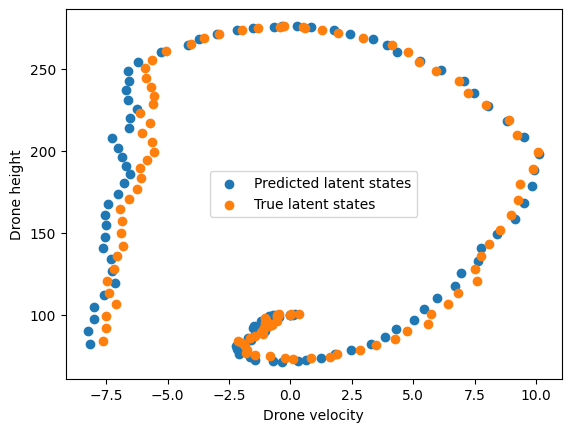

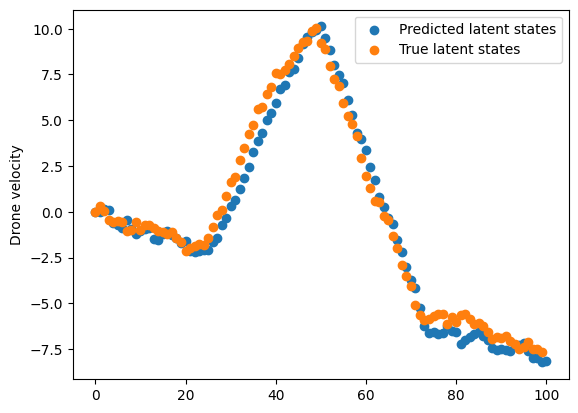

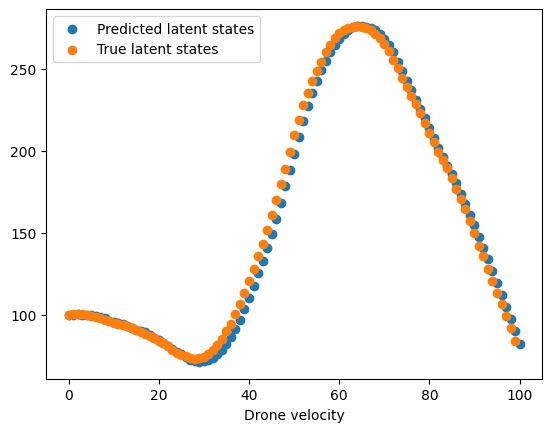

In [41]:
plt.scatter(mu.T[1], mu.T[0], label='Predicted latent states')
plt.scatter(z[1], z[0], label='True latent states')
plt.xlabel('Drone velocity')
plt.ylabel('Drone height')
plt.legend()
plt.show()

plt.scatter(t_arr, mu.T[1], label='Predicted latent states')
plt.scatter(t_arr[:-1],z[1], label='True latent states')
plt.ylabel('Drone velocity')
plt.legend()
plt.show()

plt.scatter(t_arr, mu.T[0], label='Predicted latent states')
plt.scatter(t_arr[:-1], z[0], label='True latent states')
plt.xlabel('Drone velocity')
plt.legend()
plt.show()

The true latent states are recovered well. It looks like the drone is flying in a circle.

1.3.

In [42]:
print(f'A: {A}')
print(f'C: {C}')

A: [[1. 1.]
 [0. 1.]]
C: [0.2 1. ]


1.4.

In [49]:
mu_smooth = np.zeros((T+1, n))
L_n = L[:-1]
mu_smooth[-1] = mu[-1]

for t in range(T-1, -1, -1):
    
    J_t = V[t] @ A.T @ np.linalg.inv(L_n[t])
    
    pred_t1 = A @ mu[t] + C * u[t]
    
    mu_smooth[t] = mu[t] + J_t @ (mu_smooth[t+1] - pred_t1)



1.5.

plt.scatter(mu_smooth.T[1], mu_smooth.T[0], label='Predicted latent states')
plt.scatter(z[1], z[0], label='True latent states')
plt.xlabel('Drone velocity')
plt.ylabel('Drone height')
plt.legend()
plt.show()

In [50]:
filter_mu = mu[1:]
filter_smoother_mu = mu_smooth[1:]

#print(np.shape(mu_smooth))

print(f'MSE filter estimates: {(np.square(filter_mu - z.T)).mean()}')
print(f'MSE filter-smoother estimates: {(np.square(filter_smoother_mu - z.T)).mean()}')

MSE filter estimates: 1.9944557702444763
MSE filter-smoother estimates: 1.8940941871307708


The MSE for the Kalman filter-smoother is slightly smaller than for the Kalman filter.

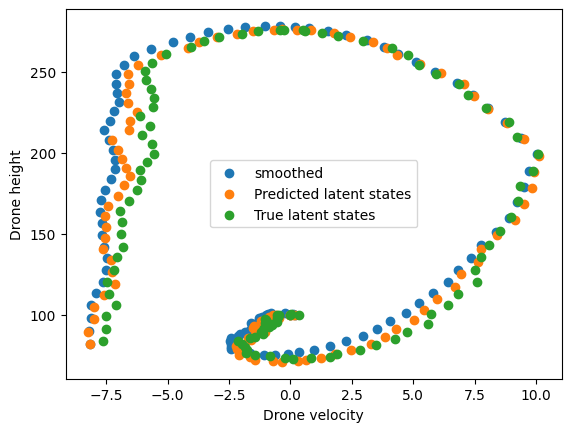

101 101
100


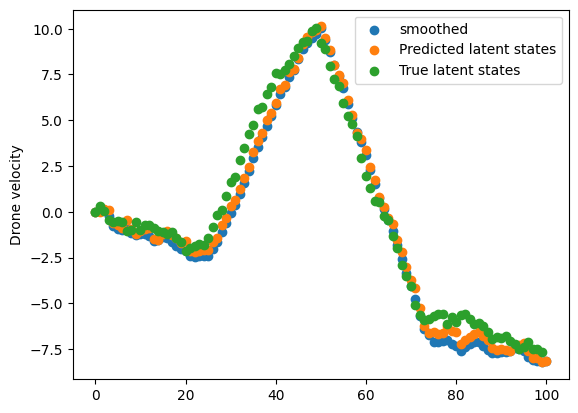

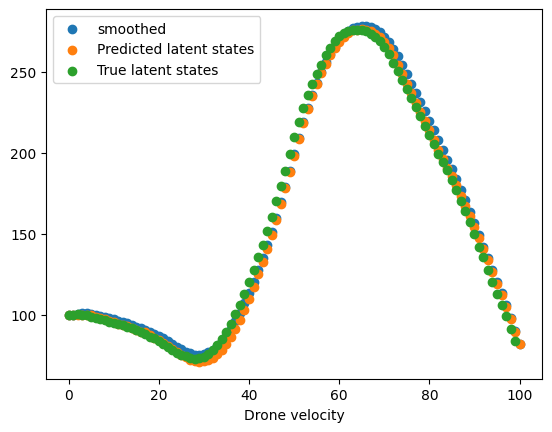

In [51]:
plt.scatter(mu_smooth.T[1], mu_smooth.T[0], label='smoothed')
plt.scatter(mu.T[1], mu.T[0], label='Predicted latent states')
plt.scatter(z[1], z[0], label='True latent states')
plt.xlabel('Drone velocity')
plt.ylabel('Drone height')
plt.legend()
plt.show()


print(len(mu_smooth.T[1]),len(t_arr))
print(len(z[1]))

plt.scatter(t_arr, mu_smooth.T[1], label='smoothed')
plt.scatter(t_arr, mu.T[1], label='Predicted latent states')
plt.scatter(t_arr[:-1],z[1], label='True latent states')
plt.ylabel('Drone velocity')
plt.legend()
plt.show()

plt.scatter(t_arr, mu_smooth.T[0], label='smoothed')
plt.scatter(t_arr, mu.T[0], label='Predicted latent states')
plt.scatter(t_arr[:-1], z[0], label='True latent states')
plt.xlabel('Drone velocity')
plt.legend()
plt.show()